In [1]:
import pandas as pd

df = pd.read_csv("../../datasets/e_sports.csv")
df

,record_id,player_id,team_name,player_role,map_played,match_type,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,1,160,Titan Esports,Flex,Dust Arena,Playoff,18,6,7,40.43,192.28,0.52,50.02,0.83,Win,No
1,2,2,Titan Esports,Support,Neon City,Final,16,7,11,40.50,201.98,0.68,41.45,0.89,Win,No
2,3,468,Team Alpha,Support,Neon City,Semi-Final,14,7,15,36.93,172.50,0.27,35.77,0.81,Win,No
3,4,447,Team Nova,IGL,Desert Storm,Final,12,6,13,53.46,246.83,0.07,43.03,1.00,Win,No
4,5,196,Phantom Squad,Sniper,Skyline,Playoff,13,9,13,44.71,266.94,0.52,39.16,0.85,Win,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,437,Titan Esports,Sniper,Desert Storm,Qualifier,16,10,14,34.77,210.97,0.89,36.49,0.79,Win,No
2796,2797,109,Red Vortex,Support,Dust Arena,Group Stage,17,9,7,43.17,201.52,0.50,52.59,0.86,Win,No
2797,2798,380,Phantom Squad,Support,Desert Storm,Final,20,9,4,26.73,220.69,0.22,56.16,1.00,Win,No
2798,2799,138,CyberX,Sniper,Skyline,Semi-Final,14,9,10,56.56,174.82,0.35,51.78,1.00,Win,No


In [2]:
df.isnull().sum()

record_id            0
player_id            0
team_name            0
player_role          0
map_played           0
match_type           0
kills                0
assists              0
deaths               0
accuracy_percent     0
reaction_time_ms     0
fatigue_index        0
performance_score    0
win_probability      0
match_outcome        0
mvp_award            0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

# SEE THE CORRELATION BETWEEN FEATURES AND TARGET

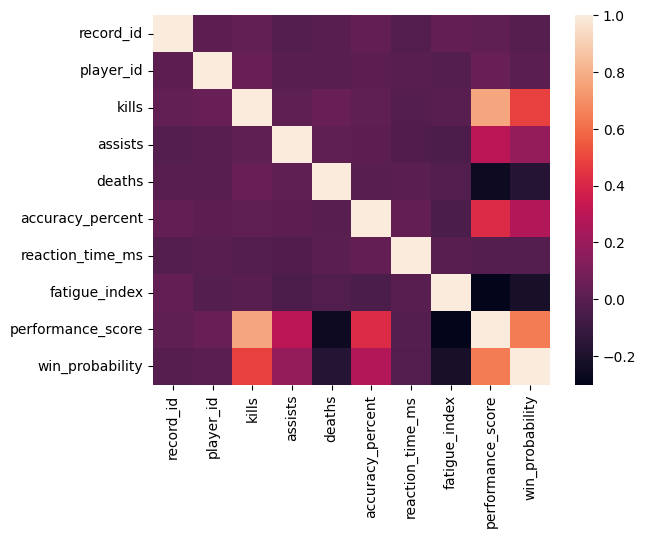

In [4]:
obj_features = ['team_name', 'player_role', 'map_played', 'match_type', 'match_outcome', 'mvp_award']
df_corr = df.drop(columns = obj_features)
corr = df_corr.corr()
import seaborn as sns
sns.heatmap(corr);

In [5]:
corr['performance_score'].sort_values(ascending = False)

# KILLS_ ACCURACY PERCENT, ASSISTIS AND FATIGUE_INDEX ARE REGRESSION STATISTICS
# ID AND PLAYER_ID ARE USELESS

performance_score    1.000000
kills                0.767174
win_probability      0.639340
accuracy_percent     0.419791
assists              0.296673
player_id            0.046736
record_id            0.020878
reaction_time_ms    -0.013608
deaths              -0.259045
fatigue_index       -0.301554
Name: performance_score, dtype: float64

In [6]:
corr['win_probability'].sort_values(ascending = False)


win_probability      1.000000
performance_score    0.639340
kills                0.481693
accuracy_percent     0.268588
assists              0.182393
player_id            0.006864
record_id           -0.008539
reaction_time_ms    -0.018460
deaths              -0.169460
fatigue_index       -0.219400
Name: win_probability, dtype: float64

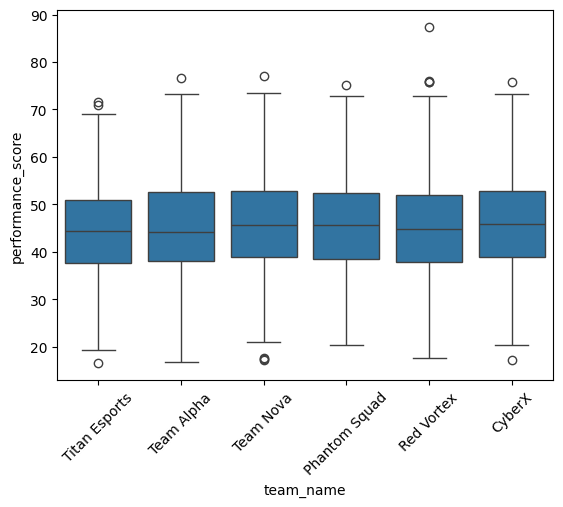

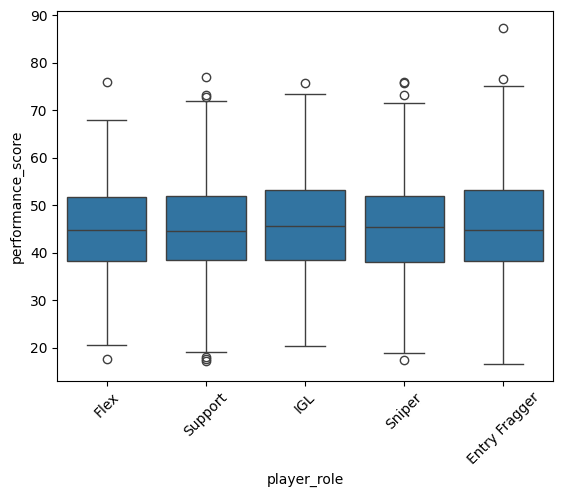

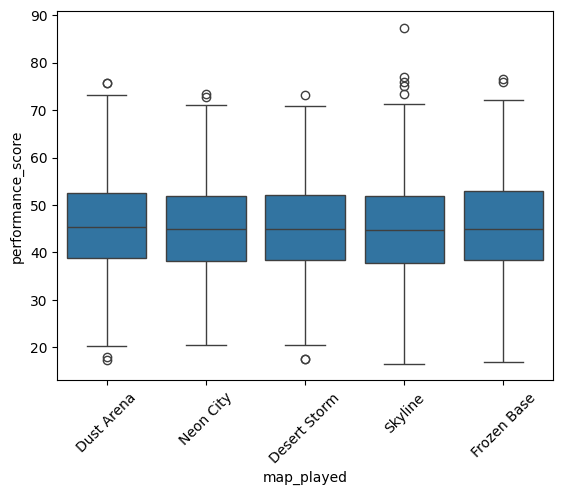

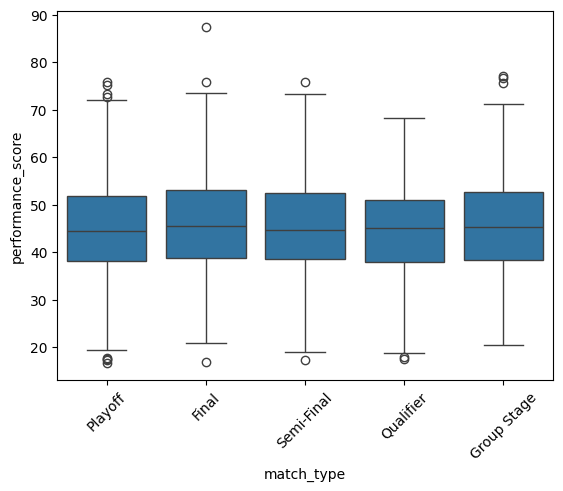

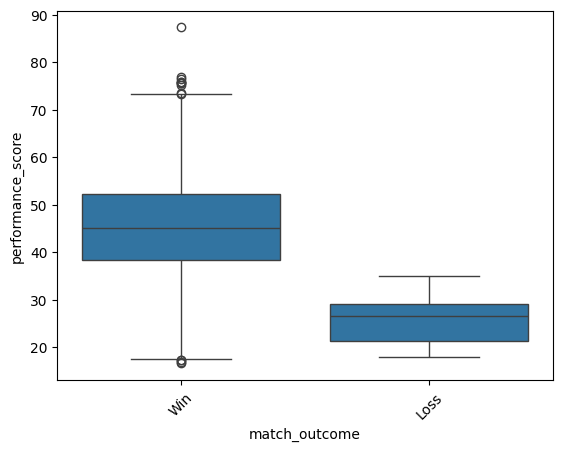

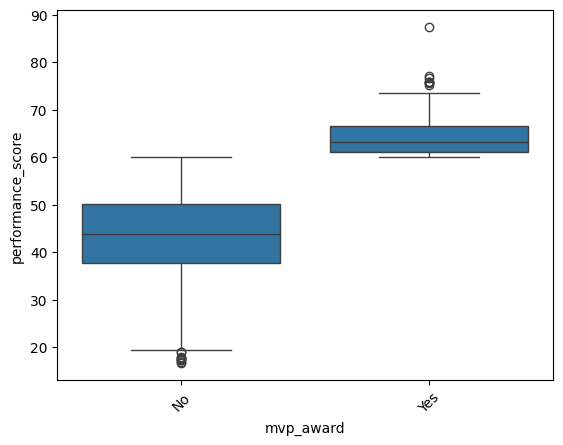

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in obj_features:
        sns.boxplot(x=feature, y="performance_score", data=df)
        plt.xticks(rotation=45)
        plt.show()

#### 'mvp_award' , 'match_outcome' are good for the model

In [8]:
df.columns

Index(['record_id', 'player_id', 'team_name', 'player_role', 'map_played',
       'match_type', 'kills', 'assists', 'deaths', 'accuracy_percent',
       'reaction_time_ms', 'fatigue_index', 'performance_score',
       'win_probability', 'match_outcome', 'mvp_award'],
      dtype='object')

In [9]:
selected_col = ['record_id', 'player_id', 'team_name', 'player_role', 'map_played', 'match_type', 'reaction_time_ms']
df.drop(columns=selected_col, inplace = True)
df

,kills,assists,deaths,accuracy_percent,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,18,6,7,40.43,0.52,50.02,0.83,Win,No
1,16,7,11,40.50,0.68,41.45,0.89,Win,No
2,14,7,15,36.93,0.27,35.77,0.81,Win,No
3,12,6,13,53.46,0.07,43.03,1.00,Win,No
4,13,9,13,44.71,0.52,39.16,0.85,Win,No
...,...,...,...,...,...,...,...,...,...
2795,16,10,14,34.77,0.89,36.49,0.79,Win,No
2796,17,9,7,43.17,0.50,52.59,0.86,Win,No
2797,20,9,4,26.73,0.22,56.16,1.00,Win,No
2798,14,9,10,56.56,0.35,51.78,1.00,Win,No


In [10]:
df['match_outcome'].unique()

array(['Win', 'Loss'], dtype=object)

In [11]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
df['match_outcome'] = encoder.fit_transform(df[['match_outcome']])
df['mvp_award'] = encoder.fit_transform(df[['match_outcome']])

df

,kills,assists,deaths,accuracy_percent,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,18,6,7,40.43,0.52,50.02,0.83,1.0,1.0
1,16,7,11,40.50,0.68,41.45,0.89,1.0,1.0
2,14,7,15,36.93,0.27,35.77,0.81,1.0,1.0
3,12,6,13,53.46,0.07,43.03,1.00,1.0,1.0
4,13,9,13,44.71,0.52,39.16,0.85,1.0,1.0
...,...,...,...,...,...,...,...,...,...
2795,16,10,14,34.77,0.89,36.49,0.79,1.0,1.0
2796,17,9,7,43.17,0.50,52.59,0.86,1.0,1.0
2797,20,9,4,26.73,0.22,56.16,1.00,1.0,1.0
2798,14,9,10,56.56,0.35,51.78,1.00,1.0,1.0


In [15]:
corr = df.corr()
corr

,kills,assists,deaths,accuracy_percent,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
kills,1.000000,0.018341,0.046680,0.020081,0.001381,0.767174,0.481693,0.092005,0.092005
assists,0.018341,1.000000,0.022381,0.008880,-0.038455,0.296673,0.182393,0.003006,0.003006
deaths,0.046680,0.022381,1.000000,0.000087,-0.022737,-0.259045,-0.169460,0.002645,0.002645
accuracy_percent,0.020081,0.008880,0.000087,1.000000,-0.043177,0.419791,0.268588,0.038058,0.038058
fatigue_index,0.001381,-0.038455,-0.022737,-0.043177,1.000000,-0.301554,-0.219400,-0.032081,-0.032081
performance_score,0.767174,0.296673,-0.259045,0.419791,-0.301554,1.000000,0.639340,0.094652,0.094652
win_probability,0.481693,0.182393,-0.169460,0.268588,-0.219400,0.639340,1.000000,0.210225,0.210225
match_outcome,0.092005,0.003006,0.002645,0.038058,-0.032081,0.094652,0.210225,1.000000,1.000000
mvp_award,0.092005,0.003006,0.002645,0.038058,-0.032081,0.094652,0.210225,1.000000,1.000000


In [19]:
corr['match_outcome'].sort_values(ascending= False)

match_outcome        1.000000
mvp_award            1.000000
win_probability      0.210225
performance_score    0.094652
kills                0.092005
accuracy_percent     0.038058
assists              0.003006
deaths               0.002645
fatigue_index       -0.032081
Name: match_outcome, dtype: float64

In [20]:
corr['mvp_award'].sort_values(ascending= False)

match_outcome        1.000000
mvp_award            1.000000
win_probability      0.210225
performance_score    0.094652
kills                0.092005
accuracy_percent     0.038058
assists              0.003006
deaths               0.002645
fatigue_index       -0.032081
Name: mvp_award, dtype: float64

In [21]:
df.describe()

,kills,assists,deaths,accuracy_percent,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,14.872500,8.027857,10.025000,45.095225,0.498875,45.306718,0.916364,0.997500,0.997500
std,3.973451,2.843157,3.178069,8.054907,0.291618,10.333504,0.097468,0.049946,0.049946
min,4.000000,0.000000,1.000000,20.460000,0.000000,16.580000,0.470000,0.000000,0.000000
25%,12.000000,6.000000,8.000000,39.542500,0.240000,38.287500,0.860000,1.000000,1.000000
50%,15.000000,8.000000,10.000000,44.960000,0.500000,44.985000,0.950000,1.000000,1.000000
75%,18.000000,10.000000,12.000000,50.552500,0.760000,52.302500,1.000000,1.000000,1.000000
max,30.000000,20.000000,22.000000,71.790000,1.000000,87.360000,1.000000,1.000000,1.000000


# The EDA analyses determine



In [23]:
print(f"Selected features for the model to preditc the 'performance_score' : {df.columns.to_list()}")
print(f"Selected PREPROCESSING METHODS for the model to object features : ORDINAL ENCODER")
print(f"Selected PREPROCESSING METHODS for the model to scale : STANDARD SCALER")



Selected features for the model to preditc the 'performance_score' : ['kills', 'assists', 'deaths', 'accuracy_percent', 'fatigue_index', 'performance_score', 'win_probability', 'match_outcome', 'mvp_award']
Selected PREPROCESSING METHODS for the model to object features : ORDINAL ENCODER
Selected PREPROCESSING METHODS for the model to scale : STANDARD SCALER
